In [1]:
%pip install lightgbm xlrd fairlearn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

# Taiwan credit default dataset
taiwan = pd.read_excel('data/default of credit card clients.xls', header=1)

# German credit dataset
german = pd.read_csv('data/german.data', sep=' ', header=None)

print("Taiwan shape:", taiwan.shape)
print("Taiwan target distribution:")
print(taiwan['default payment next month'].value_counts(normalize=True))

print("\nGerman shape:", german.shape)
print("German target distribution:")
print(german[20].value_counts(normalize=True))

Taiwan shape: (30000, 25)
Taiwan target distribution:
default payment next month
0    0.7788
1    0.2212
Name: proportion, dtype: float64

German shape: (1000, 21)
German target distribution:
20
1    0.7
2    0.3
Name: proportion, dtype: float64


In [3]:
import numpy as np

# --- Taiwan ---
taiwan_clean = taiwan.drop(columns=['ID']).copy()
taiwan_clean = taiwan_clean.rename(columns={'default payment next month': 'default'})

# Fold undocumented codes into "others"
taiwan_clean['EDUCATION'] = taiwan_clean['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
taiwan_clean['MARRIAGE'] = taiwan_clean['MARRIAGE'].replace({0: 3})

print("EDUCATION now:", sorted(taiwan_clean['EDUCATION'].unique()))
print("MARRIAGE now:", sorted(taiwan_clean['MARRIAGE'].unique()))

# --- German ---
german_cols = ['checking_status','duration','credit_history','purpose','credit_amount',
               'savings_status','employment','installment_rate','personal_status_sex',
               'other_parties','residence_since','property_magnitude','age',
               'other_payment_plans','housing','existing_credits','job',
               'num_dependents','telephone','foreign_worker','target']

german_clean = german.copy()
german_clean.columns = german_cols

# Recode target so bad credit = 1 (matches Taiwan, where default = 1)
german_clean['target'] = german_clean['target'].map({1: 0, 2: 1})

print("\nGerman target now:", german_clean['target'].value_counts(normalize=True).to_dict())
print("German shape:", german_clean.shape)

EDUCATION now: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
MARRIAGE now: [np.int64(1), np.int64(2), np.int64(3)]

German target now: {0: 0.7, 1: 0.3}
German shape: (1000, 21)


In [4]:
from sklearn.model_selection import train_test_split

# --- German: one-hot encode the categorical columns ---
X_german = pd.get_dummies(german_clean.drop(columns=['target']), drop_first=False)
y_german = german_clean['target']

print("German features after encoding:", X_german.shape)

# --- Taiwan: already numeric ---
X_taiwan = taiwan_clean.drop(columns=['default'])
y_taiwan = taiwan_clean['default']

print("Taiwan features:", X_taiwan.shape)

# --- Stratified 80/20 splits ---
Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_german, y_german, test_size=0.2, stratify=y_german, random_state=42)

Xt_train, Xt_test, yt_train, yt_test = train_test_split(
    X_taiwan, y_taiwan, test_size=0.2, stratify=y_taiwan, random_state=42)

print("\nGerman train/test:", Xg_train.shape, Xg_test.shape)
print("German bad rate - train: %.3f, test: %.3f" % (yg_train.mean(), yg_test.mean()))
print("Taiwan train/test:", Xt_train.shape, Xt_test.shape)
print("Taiwan default rate - train: %.3f, test: %.3f" % (yt_train.mean(), yt_test.mean()))

German features after encoding: (1000, 61)
Taiwan features: (30000, 23)

German train/test: (800, 61) (200, 61)
German bad rate - train: 0.300, test: 0.300
Taiwan train/test: (24000, 23) (6000, 23)
Taiwan default rate - train: 0.221, test: 0.221


In [5]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# class_weight='balanced' applied to BOTH models so the comparison is like-for-like
rf_german = RandomForestClassifier(n_estimators=300, random_state=42,
                                   class_weight='balanced').fit(Xg_train, yg_train)
rf_taiwan = RandomForestClassifier(n_estimators=300, random_state=42,
                                   class_weight='balanced').fit(Xt_train, yt_train)

lgb_german = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1,
                            class_weight='balanced').fit(Xg_train, yg_train)
lgb_taiwan = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1,
                            class_weight='balanced').fit(Xt_train, yt_train)

print("All four models trained with balanced class weights.")

for name, model, X in [("RF German", rf_german, Xg_test),
                       ("LGBM German", lgb_german, Xg_test),
                       ("RF Taiwan", rf_taiwan, Xt_test),
                       ("LGBM Taiwan", lgb_taiwan, Xt_test)]:
    probs = model.predict_proba(X)[:, 1]
    print(f"{name}: mean predicted risk = {probs.mean():.3f}")

All four models trained with balanced class weights.
RF German: mean predicted risk = 0.300
LGBM German: mean predicted risk = 0.303
RF Taiwan: mean predicted risk = 0.221
LGBM Taiwan: mean predicted risk = 0.366


In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score, confusion_matrix)

def evaluate(name, dataset, model, X_test, y_test):
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
    return {
        'Dataset': dataset, 'Model': name,
        'Accuracy': round(accuracy_score(y_test, preds), 3),
        'Precision': round(precision_score(y_test, preds), 3),
        'Recall': round(recall_score(y_test, preds), 3),
        'F1': round(f1_score(y_test, preds), 3),
        'ROC-AUC': round(roc_auc_score(y_test, probs), 3),
        'PR-AUC': round(average_precision_score(y_test, probs), 3),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    }

results = pd.DataFrame([
    evaluate('Random Forest', 'German', rf_german, Xg_test, yg_test),
    evaluate('LightGBM', 'German', lgb_german, Xg_test, yg_test),
    evaluate('Random Forest', 'Taiwan', rf_taiwan, Xt_test, yt_test),
    evaluate('LightGBM', 'Taiwan', lgb_taiwan, Xt_test, yt_test),
])
print(results.to_string(index=False))

# The "no model at all" baseline
print("\nBaseline (predict nobody defaults):")
print("  German accuracy: %.3f, recall: 0.000" % (1 - yg_test.mean()))
print("  Taiwan accuracy: %.3f, recall: 0.000" % (1 - yt_test.mean()))

# German cost matrix: missing a bad customer costs 5x a false alarm
print("\nGerman cost (5x FN + 1x FP):")
for name, model in [('Random Forest', rf_german), ('LightGBM', lgb_german)]:
    tn, fp, fn, tp = confusion_matrix(yg_test, model.predict(Xg_test)).ravel()
    print(f"  {name}: {5*fn + fp}  (FN={fn}, FP={fp})")

Dataset         Model  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  TP  FP  FN   TN
 German Random Forest     0.755      0.667   0.367 0.473    0.795   0.629  22  11  38  129
 German      LightGBM     0.740      0.571   0.533 0.552    0.774   0.629  32  24  28  116
 Taiwan Random Forest     0.812      0.640   0.342 0.446    0.760   0.538 454 255 873 4418
 Taiwan      LightGBM     0.768      0.479   0.589 0.528    0.765   0.545 781 848 546 3825

Baseline (predict nobody defaults):
  German accuracy: 0.700, recall: 0.000
  Taiwan accuracy: 0.779, recall: 0.000

German cost (5x FN + 1x FP):
  Random Forest: 201  (FN=38, FP=11)
  LightGBM: 164  (FN=28, FP=24)


In [7]:
import numpy as np

def cost_curve(model, X_test, y_test, c_fn=5, c_fp=1):
    """Expected cost across all thresholds. German ships a 5:1 cost matrix:
    approving a bad customer costs 5x declining a good one."""
    p = model.predict_proba(X_test)[:, 1]
    rows = []
    for th in np.arange(0.01, 1.00, 0.01):
        tn, fp, fn, tp = confusion_matrix(y_test, (p >= th).astype(int)).ravel()
        rows.append({'threshold': round(th, 2), 'cost': c_fn*fn + c_fp*fp,
                     'FN': fn, 'FP': fp, 'approval_rate': (p < th).mean()})
    return pd.DataFrame(rows)

for name, model in [('Random Forest', rf_german), ('LightGBM', lgb_german)]:
    c = cost_curve(model, Xg_test, yg_test)
    at50 = c[c.threshold == 0.50].iloc[0]
    best = c.loc[c.cost.idxmin()]
    print(f"{name:14s} cost@0.50={at50.cost:>4.0f}  |  "
          f"optimal th={best.threshold:.2f}  cost={best.cost:>4.0f}  "
          f"approval rate={best.approval_rate:.1%}")

Random Forest  cost@0.50= 201  |  optimal th=0.25  cost=  97  approval rate=42.5%
LightGBM       cost@0.50= 164  |  optimal th=0.01  cost= 112  approval rate=41.0%


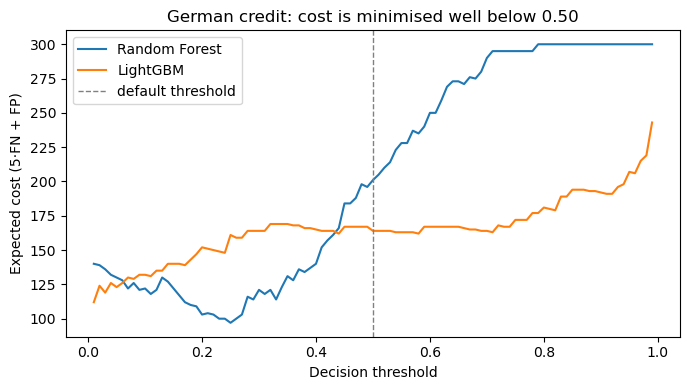

In [8]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
for name, model in [('Random Forest', rf_german), ('LightGBM', lgb_german)]:
    c = cost_curve(model, Xg_test, yg_test)
    ax.plot(c.threshold, c.cost, label=name)
ax.axvline(0.50, ls='--', c='grey', lw=1, label='default threshold')
ax.set_xlabel('Decision threshold'); ax.set_ylabel('Expected cost (5·FN + FP)')
ax.legend(); ax.set_title('German credit: cost is minimised well below 0.50')
plt.tight_layout()
plt.savefig('cost_threshold_german.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
from sklearn.inspection import permutation_importance

def gain_importance(model, X, n=10):
    """RF exposes normalised impurity importance; LGBM must be asked for 'gain'
    explicitly, or it returns raw split counts biased toward continuous features."""
    if hasattr(model, 'booster_'):
        imp = pd.Series(model.booster_.feature_importance('gain'), index=X.columns)
    else:
        imp = pd.Series(model.feature_importances_, index=X.columns)
    return (imp / imp.sum()).sort_values(ascending=False).head(n)

def perm_importance(model, X_test, y_test, n=10):
    r = permutation_importance(model, X_test, y_test, scoring='roc_auc',
                               n_repeats=10, random_state=42, n_jobs=-1)
    return pd.Series(r.importances_mean, index=X_test.columns).sort_values(ascending=False).head(n)

for label, model, Xtr, Xte, yte in [
        ('GERMAN RF', rf_german, Xg_train, Xg_test, yg_test),
        ('GERMAN LGBM', lgb_german, Xg_train, Xg_test, yg_test),
        ('TAIWAN RF', rf_taiwan, Xt_train, Xt_test, yt_test),
        ('TAIWAN LGBM', lgb_taiwan, Xt_train, Xt_test, yt_test)]:
    print(f"\n=== {label} — gain ===")
    print(gain_importance(model, Xtr).round(4).to_string())
    print(f"--- {label} — permutation (test set) ---")
    print(perm_importance(model, Xte, yte).round(4).to_string())


=== GERMAN RF — gain ===
credit_amount          0.0900
duration               0.0787
age                    0.0734
checking_status_A14    0.0653
installment_rate       0.0357
checking_status_A11    0.0329
residence_since        0.0316
credit_history_A34     0.0256
savings_status_A61     0.0225
checking_status_A12    0.0200
--- GERMAN RF — permutation (test set) ---
checking_status_A14    0.0555
checking_status_A11    0.0246
credit_amount          0.0150
duration               0.0148
credit_history_A34     0.0146
age                    0.0087
purpose_A40            0.0084
installment_rate       0.0063
other_parties_A103     0.0062
checking_status_A13    0.0057

=== GERMAN LGBM — gain ===
credit_amount              0.1818
duration                   0.1115
checking_status_A14        0.1041
age                        0.1032
installment_rate           0.0399
personal_status_sex_A93    0.0259
residence_since            0.0237
property_magnitude_A121    0.0226
savings_status_A61         0.02

/opt/anaconda3/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


PAY_0        0.0743
BILL_AMT1    0.0222
LIMIT_BAL    0.0153
PAY_AMT3     0.0114
PAY_AMT1     0.0085
PAY_AMT2     0.0076
BILL_AMT5    0.0069
PAY_2        0.0060
PAY_AMT6     0.0055
PAY_3        0.0051


## Fairness criterion

Primary: **equalised odds** — applicants from different groups should have similar chances of being correctly or incorrectly classified. In lending, this matters because a creditworthy applicant should not be more likely to be rejected because of age, sex or nationality rather than their actual credit behaviour.

Secondary: **predictive parity** — a high-risk prediction should have a similar meaning across different groups.

These two fairness measures cannot both be satisfied when the underlying default rates differ between groups, except in degenerate cases (Chouldechova 2017; Kleinberg et al. 2017). If they conflict, equalised odds is given priority because differences in error rates have a more direct effect on whether applicants are treated fairly.

This criterion was selected before calculating any fairness metrics.

In [10]:
print(german_clean['personal_status_sex'].value_counts())
print()
print(german_clean['foreign_worker'].value_counts())
print()
print(german_clean['age'].describe())

personal_status_sex
A93    548
A92    310
A94     92
A91     50
Name: count, dtype: int64

foreign_worker
A201    963
A202     37
Name: count, dtype: int64

count    1000.000000
mean       35.546000
std        11.375469
min        19.000000
25%        27.000000
50%        33.000000
75%        42.000000
max        75.000000
Name: age, dtype: float64


In [11]:
german_groups = pd.DataFrame({
    'sex': german_clean['personal_status_sex'].map(
        {'A91':'male','A93':'male','A94':'male','A92':'female'}),
    'age_band': pd.cut(german_clean['age'], bins=[0,27,42,120],
                       labels=['<=27','28-42','43+'])
})

for col in german_groups:
    print(german_groups[col].value_counts(), '\n')
print(german_clean.groupby(german_groups['sex'])['target'].mean())
print(german_clean.groupby(german_groups['age_band'], observed=True)['target'].mean())

sex
male      690
female    310
Name: count, dtype: int64 

age_band
28-42    474
<=27     291
43+      235
Name: count, dtype: int64 

sex
female    0.351613
male      0.276812
Name: target, dtype: float64
age_band
<=27     0.367698
28-42    0.280591
43+      0.255319
Name: target, dtype: float64


In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("German (n=1000):")
for name, model in [('Random Forest', rf_german), ('LightGBM', lgb_german)]:
    s = cross_val_score(model, X_german, y_german, cv=cv, scoring='roc_auc')
    print(f"  {name:14s} AUC {s.mean():.3f} +/- {s.std():.3f}")

print("\nTaiwan (n=30000):")
for name, model in [('Random Forest', rf_taiwan), ('LightGBM', lgb_taiwan)]:
    s = cross_val_score(model, X_taiwan, y_taiwan, cv=cv, scoring='roc_auc')
    print(f"  {name:14s} AUC {s.mean():.3f} +/- {s.std():.3f}")

German (n=1000):
  Random Forest  AUC 0.792 +/- 0.017
  LightGBM       AUC 0.777 +/- 0.026

Taiwan (n=30000):
  Random Forest  AUC 0.769 +/- 0.004
  LightGBM       AUC 0.771 +/- 0.006


In [13]:
protected = [c for c in X_german.columns
             if c.startswith(('personal_status_sex', 'foreign_worker')) or c == 'age']
print("Dropping:", protected)

# How much does the model rely on them?
imp = gain_importance(lgb_german, Xg_train, n=len(Xg_train.columns))
print("\nGain importance of protected attributes:")
print(imp[imp.index.isin(protected)].round(4).to_string())

# Refit without them and compare
X_fair = X_german.drop(columns=protected)
Xf_train, Xf_test, yf_train, yf_test = train_test_split(
    X_fair, y_german, test_size=0.2, stratify=y_german, random_state=42)

rf_fair = RandomForestClassifier(n_estimators=300, random_state=42,
                                 class_weight='balanced').fit(Xf_train, yf_train)
lgb_fair = LGBMClassifier(n_estimators=300, random_state=42, verbose=-1,
                          class_weight='balanced').fit(Xf_train, yf_train)

print("\n5-fold CV AUC, with vs without protected attributes:")
for name, full, fair, Xfull, Xfr in [
        ('Random Forest', rf_german, rf_fair, X_german, X_fair),
        ('LightGBM', lgb_german, lgb_fair, X_german, X_fair)]:
    a = cross_val_score(full, Xfull, y_german, cv=cv, scoring='roc_auc')
    b = cross_val_score(fair, Xfr,  y_german, cv=cv, scoring='roc_auc')
    print(f"  {name:14s} with {a.mean():.3f} +/- {a.std():.3f}   "
          f"without {b.mean():.3f} +/- {b.std():.3f}   diff {a.mean()-b.mean():+.3f}")

# And the cost consequence
print("\nOptimal cost, with vs without:")
for name, full, fair, Xte_full, Xte_fair in [
        ('Random Forest', rf_german, rf_fair, Xg_test, Xf_test),
        ('LightGBM', lgb_german, lgb_fair, Xg_test, Xf_test)]:
    c1 = cost_curve(full, Xte_full, yg_test).cost.min()
    c2 = cost_curve(fair, Xte_fair, yf_test).cost.min()
    print(f"  {name:14s} with {c1:.0f}   without {c2:.0f}   diff {c2-c1:+.0f}")

Dropping: ['age', 'personal_status_sex_A91', 'personal_status_sex_A92', 'personal_status_sex_A93', 'personal_status_sex_A94', 'foreign_worker_A201', 'foreign_worker_A202']

Gain importance of protected attributes:
age                        0.1032
personal_status_sex_A93    0.0259
personal_status_sex_A92    0.0151
personal_status_sex_A91    0.0018
foreign_worker_A201        0.0018
personal_status_sex_A94    0.0014
foreign_worker_A202        0.0001

5-fold CV AUC, with vs without protected attributes:
  Random Forest  with 0.792 +/- 0.017   without 0.785 +/- 0.029   diff +0.007
  LightGBM       with 0.777 +/- 0.026   without 0.768 +/- 0.029   diff +0.009

Optimal cost, with vs without:
  Random Forest  with 97   without 105   diff +8
  LightGBM       with 112   without 114   diff +2


In [14]:
german_groups = pd.DataFrame({
    'sex': german_clean['personal_status_sex'].map(
        {'A91':'male','A93':'male','A94':'male','A92':'female'}),
    'age_band': pd.cut(german_clean['age'], bins=[0,27,42,120],
                       labels=['<=27','28-42','43+'])
})

for col in german_groups:
    print(german_groups[col].value_counts(), '\n')
print(german_clean.groupby(german_groups['sex'])['target'].mean())
print(german_clean.groupby(german_groups['age_band'], observed=True)['target'].mean())

sex
male      690
female    310
Name: count, dtype: int64 

age_band
28-42    474
<=27     291
43+      235
Name: count, dtype: int64 

sex
female    0.351613
male      0.276812
Name: target, dtype: float64
age_band
<=27     0.367698
28-42    0.280591
43+      0.255319
Name: target, dtype: float64


In [15]:
from fairlearn.metrics import MetricFrame, selection_rate
from sklearn.metrics import recall_score, precision_score, confusion_matrix

def fnr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fn / (fn + tp) if (fn + tp) else float('nan')

def fpr(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    return fp / (fp + tn) if (fp + tn) else float('nan')

metrics = {
    'n': lambda yt, yp: len(yt),
    'base_rate': lambda yt, yp: yt.mean(),
    'flagged_rate': selection_rate,
    'TPR': lambda yt, yp: recall_score(yt, yp, zero_division=0),
    'FNR': fnr,
    'FPR': fpr,
    'precision': lambda yt, yp: precision_score(yt, yp, zero_division=0),
}

g_test_groups = german_groups.loc[Xg_test.index]

for name, model in [('Random Forest', rf_german), ('LightGBM', lgb_german)]:
    preds = model.predict(Xg_test)
    for attr in ['sex', 'age_band']:
        mf = MetricFrame(metrics=metrics, y_true=yg_test, y_pred=preds,
                         sensitive_features=g_test_groups[attr])
        print(f"\n=== {name} — by {attr} (threshold 0.50) ===")
        print(mf.by_group.round(3).to_string())


=== Random Forest — by sex (threshold 0.50) ===
            n  base_rate  flagged_rate  TPR  FNR    FPR  precision
sex                                                               
female   61.0      0.328         0.213  0.5  0.5  0.073      0.769
male    139.0      0.288         0.144  0.3  0.7  0.081      0.600

=== Random Forest — by age_band (threshold 0.50) ===
             n  base_rate  flagged_rate    TPR    FNR    FPR  precision
age_band                                                               
28-42     86.0      0.302         0.186  0.423  0.577  0.083      0.688
43+       54.0      0.185         0.093  0.200  0.800  0.068      0.400
<=27      60.0      0.400         0.200  0.375  0.625  0.083      0.750

=== LightGBM — by sex (threshold 0.50) ===
            n  base_rate  flagged_rate    TPR    FNR    FPR  precision
sex                                                                   
female   61.0      0.328         0.328  0.550  0.450  0.220      0.550
male    139.

In [16]:
taiwan_groups = pd.DataFrame({
    'sex': taiwan_clean['SEX'].map({1:'male', 2:'female'}),
    'age_band': pd.cut(taiwan_clean['AGE'], bins=[0,29,41,120],
                       labels=['<=29','30-41','42+']),
    'education': taiwan_clean['EDUCATION'].map(
        {1:'grad', 2:'university', 3:'high school', 4:'other'})
})

t_test_groups = taiwan_groups.loc[Xt_test.index]

for name, model in [('Random Forest', rf_taiwan), ('LightGBM', lgb_taiwan)]:
    preds = model.predict(Xt_test)
    for attr in ['sex', 'age_band', 'education']:
        mf = MetricFrame(metrics=metrics, y_true=yt_test, y_pred=preds,
                         sensitive_features=t_test_groups[attr])
        print(f"\n=== {name} — by {attr} (threshold 0.50) ===")
        print(mf.by_group.round(3).to_string())


=== Random Forest — by sex (threshold 0.50) ===
             n  base_rate  flagged_rate    TPR    FNR    FPR  precision
sex                                                                    
female  3598.0      0.213         0.114  0.352  0.648  0.049      0.659
male    2402.0      0.234         0.124  0.328  0.672  0.062      0.615

=== Random Forest — by age_band (threshold 0.50) ===
               n  base_rate  flagged_rate    TPR    FNR    FPR  precision
age_band                                                                 
30-41     2549.0      0.209         0.109  0.326  0.674  0.051      0.628
42+       1539.0      0.238         0.113  0.311  0.689  0.051      0.655
<=29      1912.0      0.223         0.135  0.389  0.611  0.062      0.643

=== Random Forest — by education (threshold 0.50) ===
                  n  base_rate  flagged_rate    TPR    FNR    FPR  precision
education                                                                   
grad         2130.0      0.190

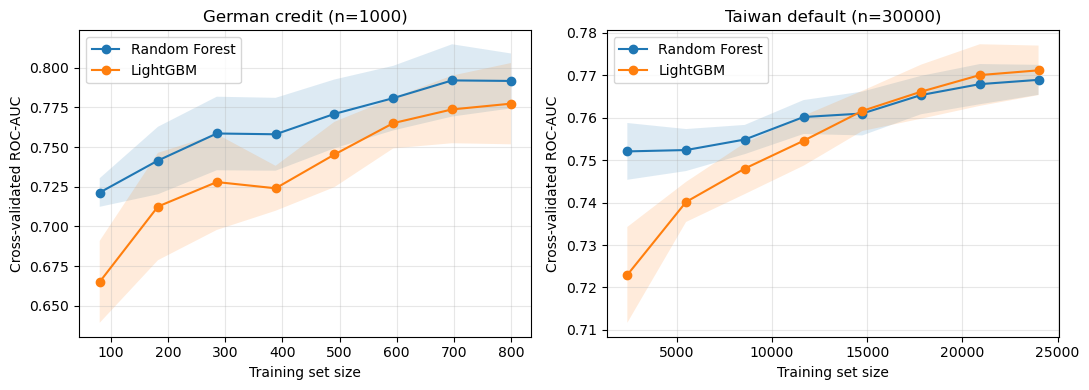

In [17]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for ax, (title, X, y, models) in zip(axes, [
    ('German credit (n=1000)', X_german, y_german,
     [('Random Forest', rf_german), ('LightGBM', lgb_german)]),
    ('Taiwan default (n=30000)', X_taiwan, y_taiwan,
     [('Random Forest', rf_taiwan), ('LightGBM', lgb_taiwan)])]):

    for name, model in models:
        sizes, train_sc, val_sc = learning_curve(
            model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 8), random_state=42)
        m, s = val_sc.mean(axis=1), val_sc.std(axis=1)
        ax.plot(sizes, m, marker='o', label=name)
        ax.fill_between(sizes, m - s, m + s, alpha=0.15)

    ax.set_title(title)
    ax.set_xlabel('Training set size')
    ax.set_ylabel('Cross-validated ROC-AUC')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
from sklearn.base import clone

def cost_at(y_true, probs, th, c_fn=5, c_fp=1):
    tn, fp, fn, tp = confusion_matrix(y_true, (probs >= th).astype(int), labels=[0,1]).ravel()
    return c_fn * fn + c_fp * fp

outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = np.arange(0.05, 0.95, 0.01)

for name, proto in [('Random Forest', rf_german), ('LightGBM', lgb_german)]:
    honest, chosen = [], []
    for tr, te in outer.split(X_german, y_german):
        Xtr, Xte = X_german.iloc[tr], X_german.iloc[te]
        ytr, yte = y_german.iloc[tr], y_german.iloc[te]

        inner = StratifiedKFold(n_splits=4, shuffle=True, random_state=0)
        inner_cost = np.zeros(len(grid))
        for itr, ite in inner.split(Xtr, ytr):
            m = clone(proto).fit(Xtr.iloc[itr], ytr.iloc[itr])
            p = m.predict_proba(Xtr.iloc[ite])[:, 1]
            inner_cost += [cost_at(ytr.iloc[ite], p, t) for t in grid]

        th = grid[inner_cost.argmin()]
        m = clone(proto).fit(Xtr, ytr)
        p = m.predict_proba(Xte)[:, 1]
        honest.append(cost_at(yte, p, th) / len(yte) * 200)
        chosen.append(th)

    print(f"{name}: honest cost {np.mean(honest):.1f} +/- {np.std(honest):.1f} "
          f"(thresholds {np.round(chosen,2)})")

Random Forest: honest cost 107.4 +/- 18.4 (thresholds [0.21 0.15 0.16 0.22 0.21])
LightGBM: honest cost 125.6 +/- 8.9 (thresholds [0.05 0.05 0.05 0.12 0.05])


In [19]:
TH = 0.20  # from nested CV on German (RF folds chose 0.15-0.22)

for name, model in [('Random Forest', rf_german), ('LightGBM', lgb_german)]:
    probs = model.predict_proba(Xg_test)[:, 1]
    preds_tuned = (probs >= TH).astype(int)
    for attr in ['sex', 'age_band']:
        mf = MetricFrame(metrics=metrics, y_true=yg_test, y_pred=preds_tuned,
                         sensitive_features=g_test_groups[attr])
        print(f"\n=== {name} — by {attr} (threshold {TH}) ===")
        print(mf.by_group.round(3).to_string())


=== Random Forest — by sex (threshold 0.2) ===
            n  base_rate  flagged_rate   TPR   FNR    FPR  precision
sex                                                                 
female   61.0      0.328         0.770  0.95  0.05  0.683      0.404
male    139.0      0.288         0.619  0.90  0.10  0.505      0.419

=== Random Forest — by age_band (threshold 0.2) ===
             n  base_rate  flagged_rate    TPR    FNR    FPR  precision
age_band                                                               
28-42     86.0      0.302         0.581  0.962  0.038  0.417      0.500
43+       54.0      0.185         0.685  0.900  0.100  0.636      0.243
<=27      60.0      0.400         0.767  0.875  0.125  0.694      0.457

=== LightGBM — by sex (threshold 0.2) ===
            n  base_rate  flagged_rate  TPR  FNR    FPR  precision
sex                                                               
female   61.0      0.328         0.426  0.7  0.3  0.293      0.538
male    139.0      

In [20]:
for name, model in [('Random Forest', rf_taiwan), ('LightGBM', lgb_taiwan)]:
    probs = model.predict_proba(Xt_test)[:, 1]
    preds_tuned = (probs >= TH).astype(int)
    for attr in ['sex', 'education']:
        mf = MetricFrame(metrics=metrics, y_true=yt_test, y_pred=preds_tuned,
                         sensitive_features=t_test_groups[attr])
        print(f"\n=== {name} — by {attr} (threshold {TH}) ===")
        print(mf.by_group.round(3).to_string())


=== Random Forest — by sex (threshold 0.2) ===
             n  base_rate  flagged_rate    TPR    FNR    FPR  precision
sex                                                                    
female  3598.0      0.213         0.344  0.658  0.342  0.258      0.408
male    2402.0      0.234         0.395  0.684  0.316  0.307      0.405

=== Random Forest — by education (threshold 0.2) ===
                  n  base_rate  flagged_rate    TPR    FNR    FPR  precision
education                                                                   
grad         2130.0      0.190         0.300  0.630  0.370  0.223      0.398
high school  1014.0      0.257         0.422  0.667  0.333  0.337      0.407
other          82.0      0.061         0.183  0.600  0.400  0.156      0.200
university   2774.0      0.236         0.397  0.695  0.305  0.305      0.414

=== LightGBM — by sex (threshold 0.2) ===
             n  base_rate  flagged_rate    TPR    FNR    FPR  precision
sex                              

In [21]:
import json
print("learning_curves.png saved")

learning_curves.png saved


In [22]:
import os
print(os.path.abspath('learning_curves.png'))

/Users/shouryapratapsingh/case-studies-credit-risk/learning_curves.png
